**NAME-VAISHNAV BALPANDE\
SECTION-C2\
ROLL NO-B1-01\
SUBJECT-ML LAB\
PRACTICAL-5**

**Practical 5**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")


In [2]:
df = pd.read_csv('diabetes.csv')
print(df.head())
print(f"\nDataset shape: {df.shape}")


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape: (768, 9)


**1. KNN Classification (Predicting 'Outcome')**

Best K for Classification: 19 with accuracy: 0.7446


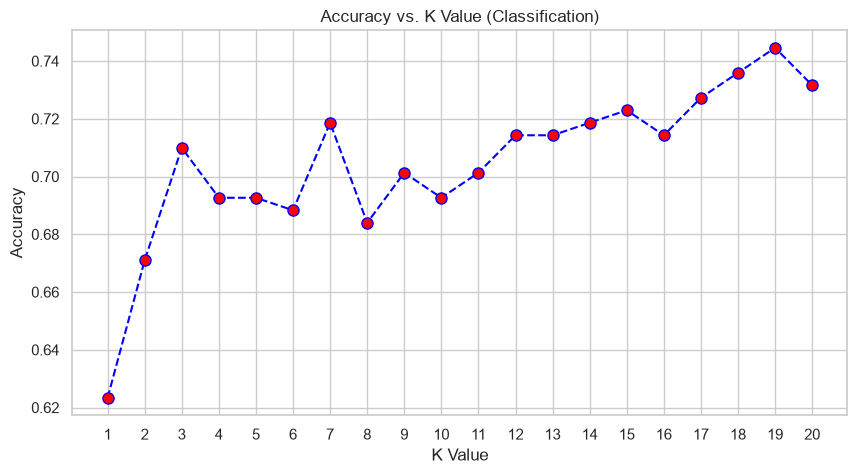

In [3]:
X_class = df.drop('Outcome', axis=1)
y_class = df['Outcome']

scaler_class = StandardScaler()
X_class_scaled = scaler_class.fit_transform(X_class)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class_scaled, y_class, test_size=0.3, random_state=42)

k_values = range(1, 21)
accuracies = []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_c, y_train_c)
    y_pred_c = clf.predict(X_test_c)
    accuracies.append(accuracy_score(y_test_c, y_pred_c))

best_k_c = k_values[np.argmax(accuracies)]
print(f"Best K for Classification: {best_k_c} with accuracy: {max(accuracies):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='blue', markerfacecolor='red', markersize=8)
plt.title('Accuracy vs. K Value (Classification)')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       151
           1       0.67      0.51      0.58        80

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.74      0.74      0.73       231

Confusion Matrix:


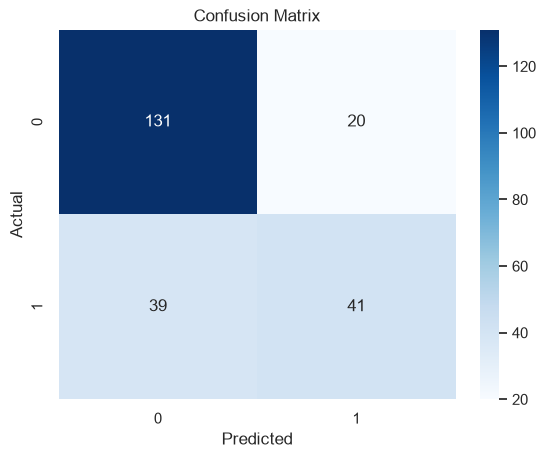

In [4]:
best_clf = KNeighborsClassifier(n_neighbors=best_k_c)
best_clf.fit(X_train_c, y_train_c)
y_pred_best_c = best_clf.predict(X_test_c)

print("Classification Report:")
print(classification_report(y_test_c, y_pred_best_c))

print("Confusion Matrix:")
cm = confusion_matrix(y_test_c, y_pred_best_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**2. KNN Regression (Predicting 'BMI')**
We will use KNN Regressor to predict the 'BMI' continuous variable based on the other features, excluding 'Outcome' just to focus on physiological features.


Best K for Regression: 11 with R2 Score: 0.2607


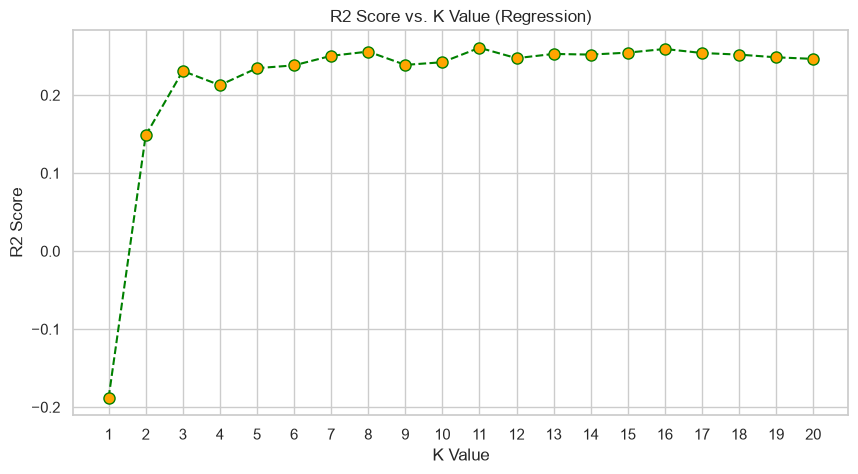

In [5]:
X_reg = df.drop(['BMI', 'Outcome'], axis=1)
y_reg = df['BMI']

scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg_scaled, y_reg, test_size=0.3, random_state=42)

r2_scores = []
mse_scores = []

for k in k_values:
    reg = KNeighborsRegressor(n_neighbors=k)
    reg.fit(X_train_r, y_train_r)
    y_pred_r = reg.predict(X_test_r)
    r2_scores.append(r2_score(y_test_r, y_pred_r))
    mse_scores.append(mean_squared_error(y_test_r, y_pred_r))

best_k_r = k_values[np.argmax(r2_scores)]
print(f"Best K for Regression: {best_k_r} with R2 Score: {max(r2_scores):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_values, r2_scores, marker='o', linestyle='dashed', color='green', markerfacecolor='orange', markersize=8)
plt.title('R2 Score vs. K Value (Regression)')
plt.xlabel('K Value')
plt.ylabel('R2 Score')
plt.xticks(k_values)
plt.show()


Regression Metrics:
Mean Squared Error (MSE): 52.8608
Root Mean Squared Error (RMSE): 7.2705
R-squared (R2): 0.2607


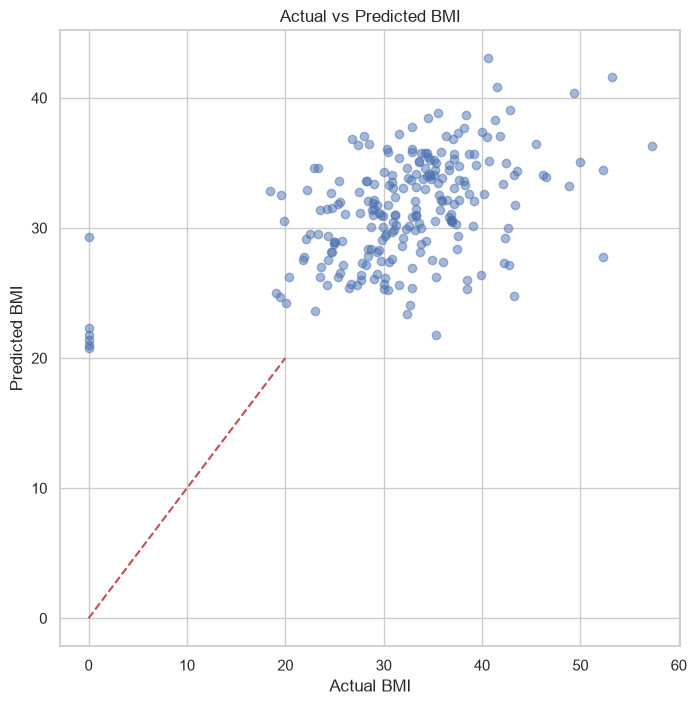

In [6]:
best_reg = KNeighborsRegressor(n_neighbors=best_k_r)
best_reg.fit(X_train_r, y_train_r)
y_pred_best_r = best_reg.predict(X_test_r)

print("Regression Metrics:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_r, y_pred_best_r):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_r, y_pred_best_r)):.4f}")
print(f"R-squared (R2): {r2_score(y_test_r, y_pred_best_r):.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test_r, y_pred_best_r, alpha=0.5)
plt.plot([y_test_r.min(), y_test_r.min() + 20], [y_test_r.min(), y_test_r.min() + 20], 'r--')
plt.xlabel('Actual BMI')
plt.ylabel('Predicted BMI')
plt.title('Actual vs Predicted BMI')
plt.show()
